## Word Matching with a bipartite weighted graph

In this section, we'll show the matching of our reference sentence to the hypothesis transcript. The alignment is modelled as finding the min-cost max-flow in a bipartite network.

In [1]:
import sys
import importlib
from pathlib import Path

# locate project root by walking up until requirements.txt is found
_anchor = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in (_anchor, *_anchor.parents) if (p / "requirements.txt").exists())
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "domain"))
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "utils"))

import pandas as pd

import preprocessing
import word_similarity_calculator
import bipartite_matching
import plot_helpers
importlib.reload(preprocessing)
importlib.reload(word_similarity_calculator)
importlib.reload(bipartite_matching)
importlib.reload(plot_helpers)

from word_similarity_calculator import WordSimilarityCalculator
from bipartite_matching import build_full_bipartite_graph, solve_matching, get_node_name, extract_index_from_node_name, REFERENCE_PARTITION, ATTR_WORD, ATTR_SIMILARITY
from preprocessing import clean_word
from plot_helpers import plot_bipartite_graph_full, plot_reduced_bipartite_graph_with_matching

In [2]:
# Pick a sentence by path (from STT4SG-350 train_all) and which model to align against.
SENTENCE_PATH = "97ce7ab5-53c1-42b4-9c80-9d48891ccf49/a385b8ae12c949748a55730f48295d77cebeac08b3b3435349e32299a121e0ad.flac"  # e.g., "clips_wav/zh/abc123.wav"
MODEL = "dat"  # "dat" (FHNW dialect-aware) or "dit" (Whisper-large-v2 dialect-ignorant)

DAT_TSV = PROJECT_ROOT / "transcripts" / "dialect-aware" / "fhnw" / "stt4sg" / "train_all_transcribed.tsv"
DIT_TSV = PROJECT_ROOT / "transcripts" / "dialect-ignorant" / "whisper-large-v2" / "stt4sg" / "train_all_enriched_transcribed_praet.tsv"

dat = pd.read_csv(DAT_TSV, sep="\t", encoding="utf-8-sig",
                  usecols=["path", "sentence", "fhnw_transcript", "dialect_region"]).set_index("path")
dit = pd.read_csv(DIT_TSV, sep="\t", encoding="utf-8-sig",
                  usecols=["path", "whisper_large_v2_transcript"]).set_index("path")

reference = dat.loc[SENTENCE_PATH, "sentence"]
hypothesis = (dat.loc[SENTENCE_PATH, "fhnw_transcript"] if MODEL == "dat"
              else dit.loc[SENTENCE_PATH, "whisper_large_v2_transcript"])

ref = [w for w in (clean_word(t) for t in reference.split()) if w]
hyp = [w for w in (clean_word(t) for t in hypothesis.split()) if w]

print(f"Path:       {SENTENCE_PATH}  ({dat.loc[SENTENCE_PATH, 'dialect_region']})")
print(f"Model:      {MODEL.upper()}")
print(f"Reference:  {reference}")
print(f"Hypothesis: {hypothesis}")

n_r = len(ref)
n_h = len(hyp)
N = n_r + n_h

# Calibrated hyperparameters — must match build_alignment_table.py.
calculator = WordSimilarityCalculator(
    alpha=0.85,
    lambda_=0.45,
    use_global_lexical_normalization=False,
    use_squared_positional=True,
    sent_len=max(n_r, n_h),
)

G = build_full_bipartite_graph(
    ref,
    hyp,
    calculator=calculator,
)
matching = solve_matching(G)

# row 1: reference
ref_row = list(ref)

# row 2: matched hypothesis word per reference position, or epsilon
hypothesis_row = []
similarity_row = []
for i in range(n_r):
    ref_word = ref[i]
    hyp_node = matching[get_node_name(REFERENCE_PARTITION, i)]
    hyp_word = G.nodes[hyp_node][ATTR_WORD]
    similarity = G.edges[get_node_name(REFERENCE_PARTITION, i), hyp_node][ATTR_SIMILARITY]
    if similarity is not None:
        hyp_idx = extract_index_from_node_name(hyp_node)
        hypothesis_row.append(f"{hyp_word} [{hyp_idx + 1}]")
        similarity_row.append(f"{similarity:.3f}")
    else:
        hypothesis_row.append(hyp_word)
        similarity_row.append("ε")

# row 3: hypothesis in transcribed order
hyp_row = list(hyp)

# build df
df_alignment = pd.DataFrame(
    [ref_row, hypothesis_row, hyp_row, similarity_row],
    index=["Reference", "Hypothesis (matched)", "Hypothesis (original)", "Similarity"],
)
df_alignment.columns = range(1, max(n_h, n_r) + 1)
df_alignment

Path:       97ce7ab5-53c1-42b4-9c80-9d48891ccf49/a385b8ae12c949748a55730f48295d77cebeac08b3b3435349e32299a121e0ad.flac  (Innerschweiz)
Model:      DAT
Reference:  Das Pferd ist wie ein Spiegel.
Hypothesis: Die Strasse ist wie ein Spiegel.


,1,2,3,4,5,6
Reference,das,pferd,ist,wie,ein,spiegel
Hypothesis (matched),strasse [2],die [1],ist [3],wie [4],ein [5],spiegel [6]
Hypothesis (original),die,strasse,ist,wie,ein,spiegel
Similarity,0.436,0.308,1.000,1.000,1.000,1.000


## Visualization

### Complete Graph

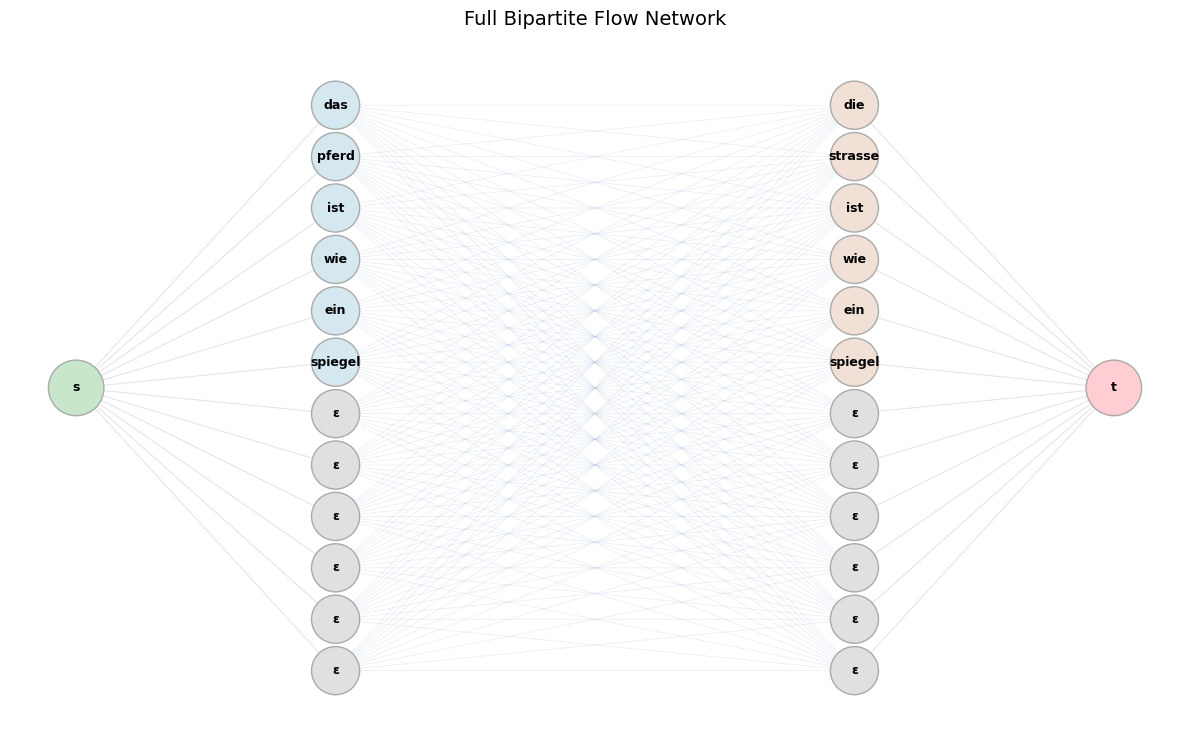

In [3]:
plot_bipartite_graph_full(G)

### Reduced Graph with Matching

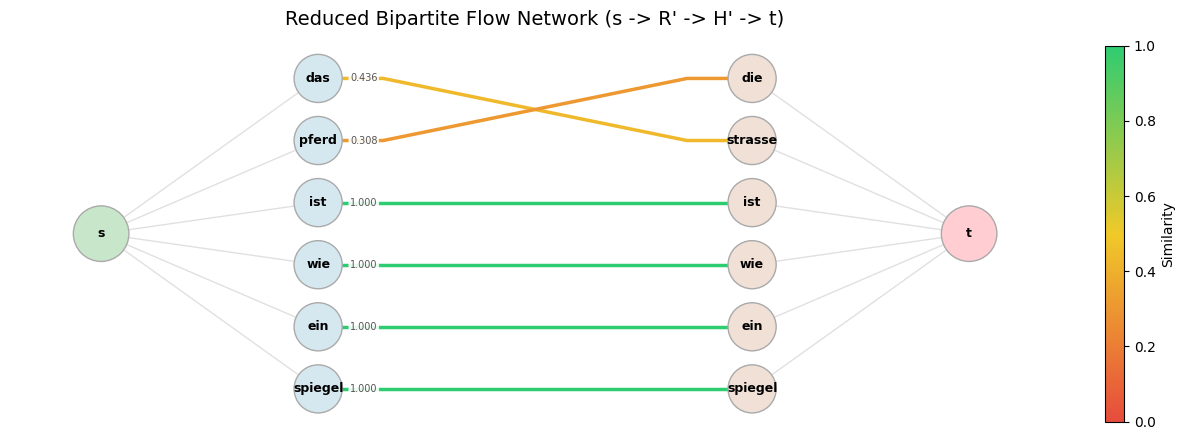

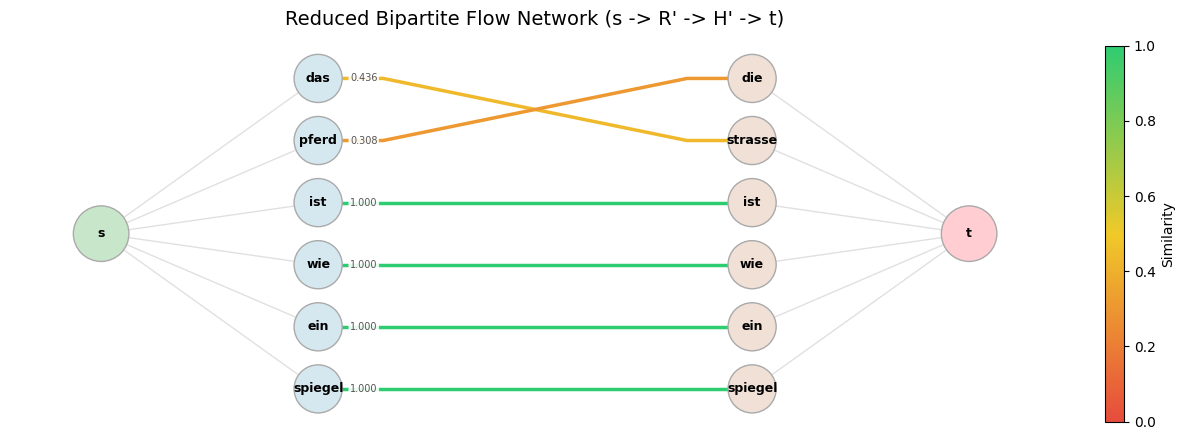

In [4]:
plot_reduced_bipartite_graph_with_matching(G, matching)